# Analyze of the light distribution

In [1]:
import pandas as pd
import tqdm
import numpy as np
import glob
from collections import defaultdict

def read_params(path):
    params = pd.read_csv(path, header=None, sep=" ", index_col=False, lineterminator='\n')
    params.rename(columns={0:'img_name'}, inplace=True)
    params = params.set_index('img_name').T.to_dict('list')
    return params

def swap_key(params):
    params_s = defaultdict(dict)
    for params_name, v in params.items():
        for img_name, params_value in v.items():
            params_s[img_name][params_name] = np.array(params_value).astype(np.float64)

    return params_s

def load_deca_params(deca_dir, cfg):
    deca_params = {}

    # face params 
    params_key = ['light']
    for k in tqdm.tqdm(params_key, desc="Loading deca params..."):
        params_path = glob.glob(f"{deca_dir}/*{k}-anno.txt")
        for path in params_path:
            deca_params[k] = read_params(path=path)
    
    deca_params = swap_key(deca_params)
    return deca_params

In [2]:
training_data = '/data/mint/DPM_Dataset/ffhq_256_with_anno/'
images = f'{training_data}/ffhq_256/train/'
light_file = f'{training_data}/params/train/ffhq-train-light-anno.txt'
sh = read_params(light_file)



In [ ]:
import misc, os
import torch as th
from PIL import Image
out_dir_wclip = '/data/mint/DPM_Dataset/ffhq_256_with_anno/ball/clip/train/'
out_dir_woclip = '/data/mint/DPM_Dataset/ffhq_256_with_anno/ball/woclip/train/'
os.makedirs(out_dir_wclip, exist_ok=True)
os.makedirs(out_dir_woclip, exist_ok=True)
for sh_k in tqdm.tqdm(sh.keys()):
    img_name = sh_k.split('/')[-1].split('.')[0]
    tmp_wclip, tmp_woclip = misc.drawSphere(sh=th.tensor(sh[sh_k]).view(9, 3))
    Image.fromarray((tmp_wclip.permute(1, 2, 0).cpu().numpy() * 255.).astype(np.uint8)).save(f'{out_dir_wclip}/{img_name}.png')
    tmp_wclip = tmp_wclip.permute(1, 2, 0).cpu().numpy()
    np.save(f'{out_dir_woclip}/{img_name}.npy', tmp_wclip)


  0%|          | 0/60000 [00:00<?, ?it/s]


AssertionError: 

[[0.2820948 ]
 [1.0233268 ]
 [1.0233268 ]
 [1.0233268 ]
 [0.8580855 ]
 [0.8580855 ]
 [0.8580855 ]
 [0.42904276]
 [0.24770796]]


[{'16692.jpg': array([[-0.98405302]])}, {'11454.jpg': array([[-0.98461912]])}, {'29245.jpg': array([[-0.98496118]])}, {'413.jpg': array([[-0.98517932]])}, {'20122.jpg': array([[-0.98557986]])}, {'4381.jpg': array([[-0.98590617]])}, {'57183.jpg': array([[-0.98646512]])}, {'30976.jpg': array([[-0.98655134]])}, {'49954.jpg': array([[-0.98679805]])}, {'20618.jpg': array([[-0.98709012]])}, {'34408.jpg': array([[-0.98721955]])}, {'21150.jpg': array([[-0.98790765]])}, {'47695.jpg': array([[-0.98815628]])}, {'42991.jpg': array([[-0.98817377]])}, {'51481.jpg': array([[-0.98823913]])}, {'39476.jpg': array([[-0.98830592]])}, {'10029.jpg': array([[-0.98854445]])}, {'54895.jpg': array([[-0.9886974]])}, {'12846.jpg': array([[-0.98883941]])}, {'1321.jpg': array([[-0.98887882]])}, {'57526.jpg': array([[-0.98975847]])}, {'43226.jpg': array([[-0.99014491]])}, {'53251.jpg': array([[-0.99067132]])}, {'50611.jpg': array([[-0.99076863]])}, {'25068.jpg': array([[-0.99113776]])}, {'56852.jpg': array([[-0.9913

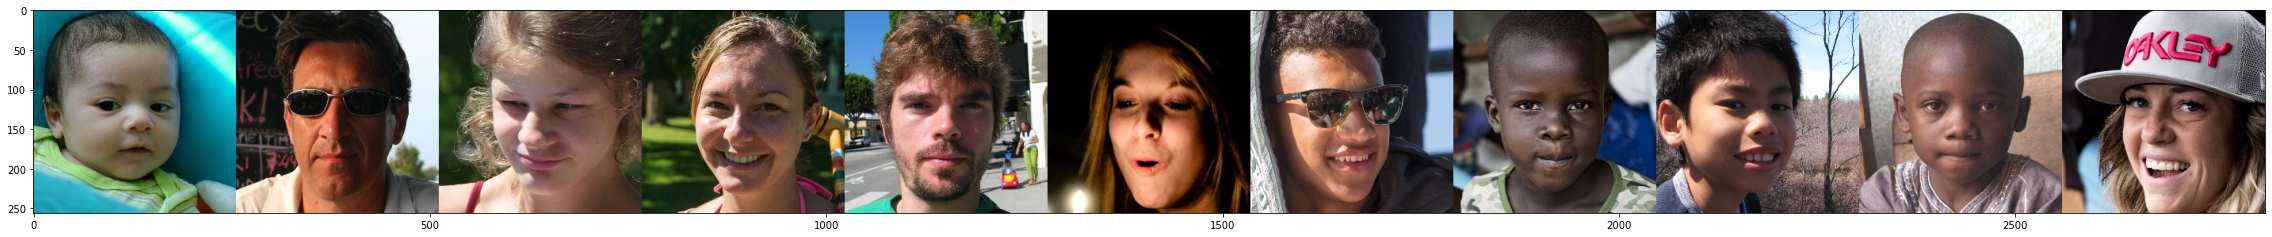

In [67]:
pi = np.pi
constant_factor = np.array([1/np.sqrt(4*pi), ((2*pi)/3)*(np.sqrt(3/(4*pi))), ((2*pi)/3)*(np.sqrt(3/(4*pi))),
                    ((2*pi)/3)*(np.sqrt(3/(4*pi))), (pi/4)*(3)*(np.sqrt(5/(12*pi))), (pi/4)*(3)*(np.sqrt(5/(12*pi))),
                    (pi/4)*(3)*(np.sqrt(5/(12*pi))), (pi/4)*(3/2)*(np.sqrt(5/(12*pi))), (pi/4)*(1/2)*(np.sqrt(5/(4*pi)))]).astype(np.float32)
constant_factor = constant_factor[..., None]
print(constant_factor)

from sklearn.metrics.pairwise import cosine_similarity

def compute_distance(inp_sh, ref_sh, constant_factor, img_name, dist_type='l2'):
    inp_sh = np.array(inp_sh).reshape(9, 3)
    ref_sh = np.array(ref_sh).reshape(9, 3)
    if dist_type == 'l2':
        dist = np.mean(np.sum(np.square(inp_sh - ref_sh) * constant_factor, axis=1))
    elif dist_type == 'cosine_sim':
        dist = cosine_similarity(inp_sh, ref_sh)
        dist = np.mean(dist * constant_factor)
    elif dist_type == 'cosine_sim_W':
        inp_sh = np.mean(inp_sh * constant_factor, axis=0, keepdims=True)
        ref_sh = np.mean(ref_sh * constant_factor, axis=0, keepdims=True)
        dist = cosine_similarity(inp_sh, ref_sh)
    return {img_name : dist}

# multiprocess to compute distance
from multiprocessing import Pool

src_img = '0.jpg'
n_compute = 60000
dist_type = 'cosine_sim_W'
tgt_img = list(sh.keys())[1:n_compute]
with Pool(10) as p:
    dist_dict = p.starmap(compute_distance, [(sh[src_img], sh[tgt_img[i]], constant_factor, tgt_img[i], dist_type) for i in range(0, len(tgt_img))])

if dist_type == 'l2':
    sorted_dist = sorted(dist_dict, key=lambda x: list(x.values())[0])
elif dist_type in ['cosine_sim', 'cosine_sim_W']:
    sorted_dist = sorted(dist_dict, key=lambda x: list(x.values())[0], reverse=True)
    
# Show top n images in grid
import matplotlib.pyplot as plt
from PIL import Image
top_n = [Image.open(images + src_img)]
n = 10
for k in sorted_dist[-n:]:
    img = Image.open(images + list(k.keys())[0])
    top_n.append(img)

print(sorted_dist[-100:])
top_n = np.concatenate(top_n, axis=1)
plt.figure(figsize=(40, 40))
plt.imshow(top_n)
plt.show()
    